# π0

π0 是 Physical Intelligence 提出的**通用机器人策略（robot foundation model）**：用一个预训练的视觉-语言模型（PaliGemma 3B）做主干，外加一组专门处理机器人状态与动作的权重（**action expert**，300M），用**条件流匹配（flow matching）**直接生成**连续动作块**（H = 50 步），从而在约 10,000 小时跨本体数据上预训练、再用少量高质量数据后训练，完成叠衣服、清理餐桌、组装纸箱等长程灵巧任务。

**最该记住的三件事**

1. **动作表示换代**：此前 VLA（RT-2、OpenVLA）把动作离散成 256 个桶、当作文本 token 自回归输出；π0 改成"**连续 + 流匹配 + 动作块**"，因此能支持最高 50 Hz 的精细控制。
2. **规模反而更小**：3.3B 参数（3B + 300M），却在自己的评测中全面超过 7B 的 OpenVLA 与 93M 的 Octo，连 470M、无 VLM 初始化的 π0-small 也超过它们。
3. **配方比架构重要**：明确区分**预训练（学广度、学纠错）**与**后训练（学熟练、学流畅）**，并给出"多样但低质的数据 + 少量高质量数据"互补的实验证据。

## 问题与主张

### 问题

通用机器人策略面临三个瓶颈：
- **规模**——预训练收益要在很大规模上才显现；
- **架构**——要能同时吃下多样数据源、又能表达精细连续动作；
- **训练配方**——数据该怎么配、怎么分阶段。

前代 VLA 的共性缺陷：用**自回归离散化**表示动作，逐 token 解码，不支持<mark>动作分块（action chunking）</mark>与<mark>高频控制</mark>，因此在灵巧任务上受限。


### 论文主张（三条贡献）

1. 一个基于 **VLM 预训练 + 流匹配**的新型通用机器人策略架构（π0）；
2. 对这类基础模型**预训练 / 后训练配方**的实证研究；
3. 覆盖**开箱提示、语言跟随、微调新任务、复杂多阶段任务**四类评测，并展示显著超越此前模型的灵巧性与通用性。

## 方法

### 架构总览

| 组件                           | 说明                                                         |
| ------------------------------ | ------------------------------------------------------------ |
| VLM 主干                       | PaliGemma（开源 3B），提供互联网规模的语义知识               |
| action expert                  | 300M，**从零初始化**，负责机器人状态与动作 token；与主干**只在自注意力层交互**（可理解为 2 专家 MoE） |
| 总参数                         | 3.3B（3B + 300M）                                            |
| 输入                           | 观测 $o_t = [I¹…Iⁿ 图像, ℓ 语言 token, q 关节角]$，图像/状态各自编码后线性投影进语言嵌入空间（晚期融合） |
| 输出                           | 动作块 $A_t = [a_t, …, a_{t+H−1}]$，**H = 50**                 |
| 注意力掩码                     | 块状因果掩码 3 块：[图像+语言]、[状态 q_t]、[带噪动作]；块内双向、块间不看未来；让 q_t 单独成块以便缓存 KV |
| 关键设计差异（相对 PaliGemma） | ①机器人 token 的输入/输出投影；②引入流匹配时间步 τ 的 MLP；③action expert 的第二组权重 |


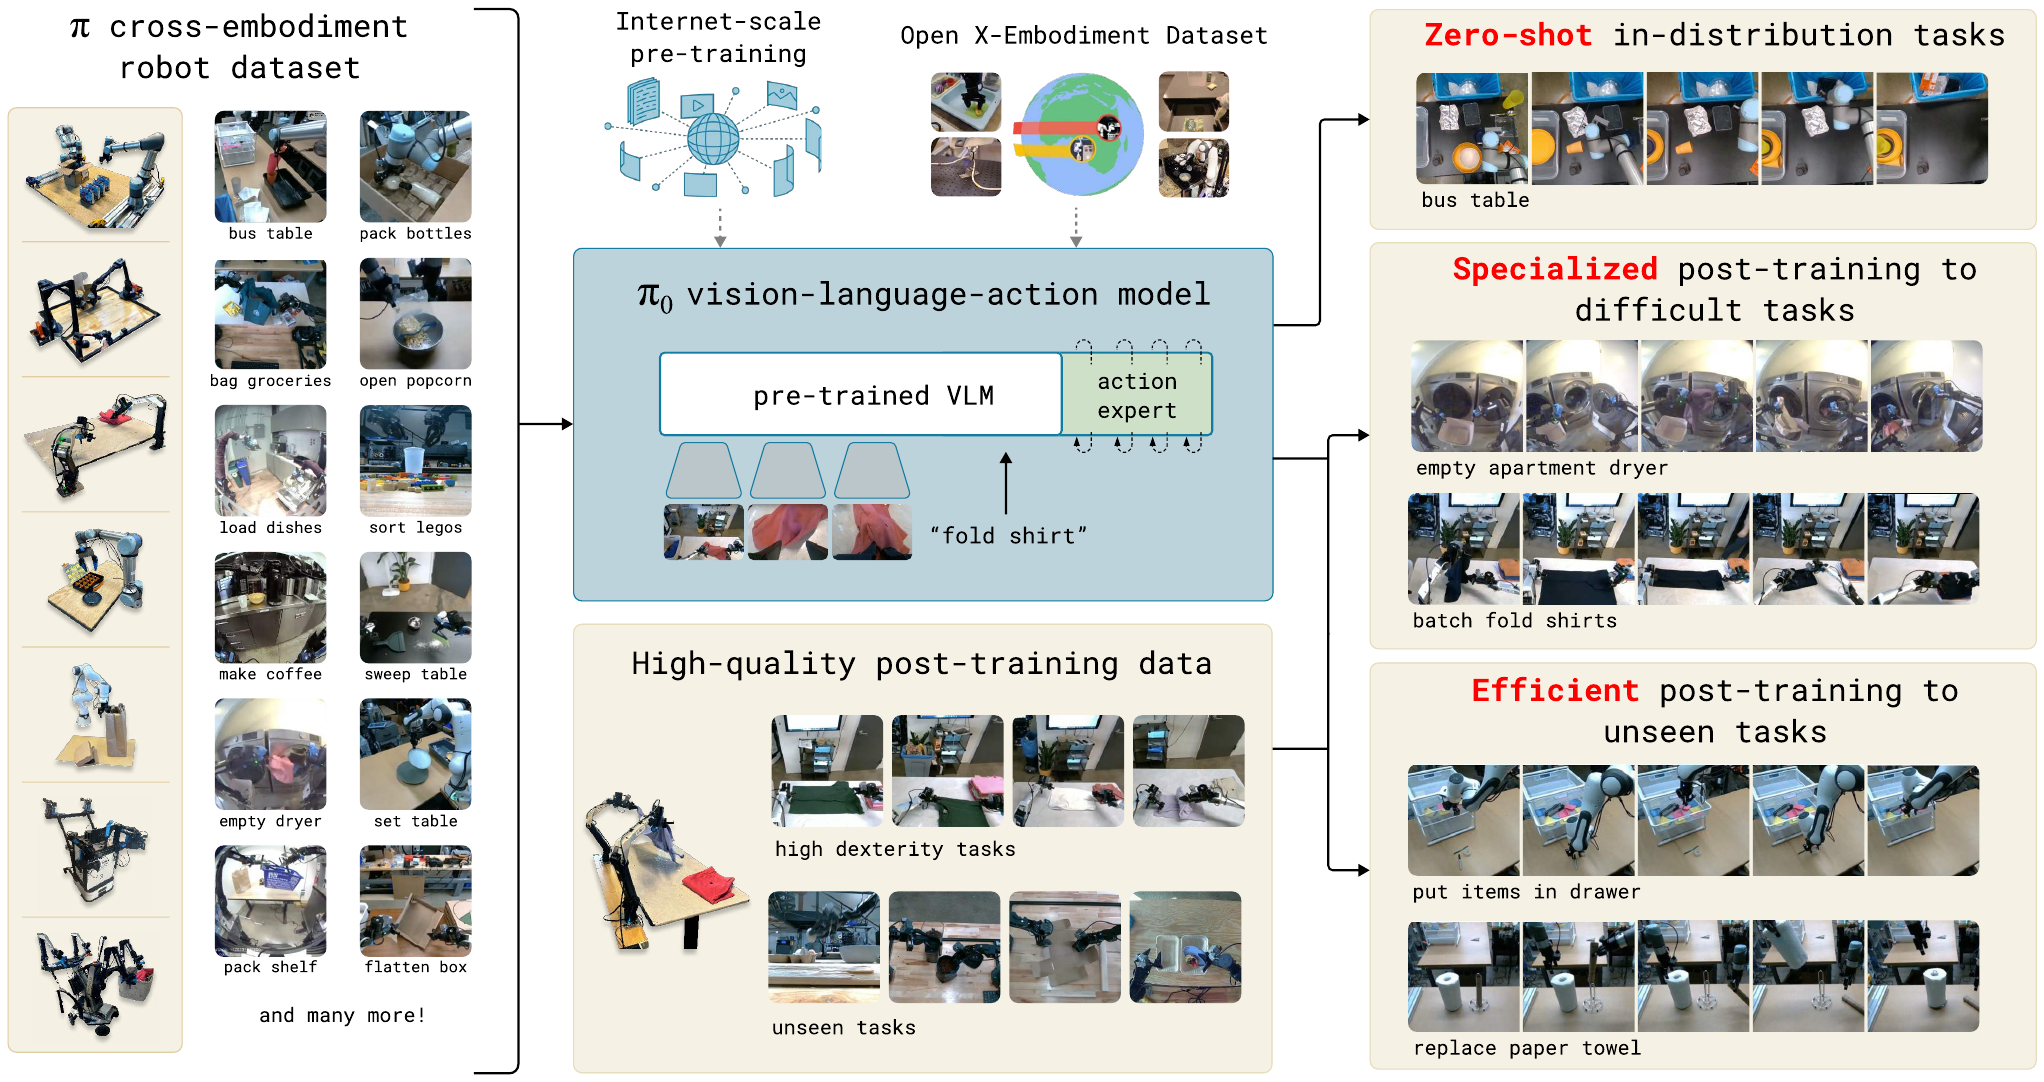

### 流匹配目标

以“真实动作块减噪声”为速度监督，学习如何根据观测逐步修改带噪动作块；推理时从高斯噪声出发，通过 10 步积分生成 50 步连续动作预测 $A=[a_t,a_{t+1},\ldots,a_{t+49}]$。

1. 训练时：人为构造“噪声到正确动作”的路径

训练数据提供观测 $o$ 和真实动作块 $A$。这里 $o$ 包括相机图像、语言指令和机器人状态。

我们采样一个与动作块形状相同的高斯噪声 $\epsilon$，再选一个生成进度 $\tau$，构造：

$$A^\tau=(1-\tau)\epsilon+\tau A$$

因此：

| 生成进度 | 构造出来的动作块 |
| :--- | :--- |
| $\tau=0$ | 纯噪声 $\epsilon$ |
| $\tau=0.5$ | 一半噪声、一半真实动作 |
| $\tau=1$ | 真实动作 $A$ |

这条人为构造的路径是直线，它沿生成时间的变化速度为：

$$\frac{dA^\tau}{d\tau}=A-\epsilon$$

这个差值就是训练所需的监督信号。


2. 模型学什么：预测当前应该怎样修改动作块

动作专家接收当前带噪动作块 $A^\tau$、进度 $\tau$ 和观测 $o$，预测一个<mark>速度场</mark>：
$$
v_\theta(A^\tau,\tau,o)
$$
训练目标是让预测接近刚才的目标速度：
$$
\mathcal L=
\mathbb E_{A,o,\epsilon,\tau}
\left[
\left\|
v_\theta(A^\tau,\tau,o)-(A-\epsilon)
\right\|^2
\right]
$$
可以把它读成一句话：
“在这个场景和任务下，当前这块带噪的动作，应该往哪个方向修改、修改多大？”

这里的“速度”是动作块在生成过程中的变化率，不等于机器人关节实际运动的速度。
训练时我们知道正确动作 $A$，所以能计算监督信号；推理时没有正确动作，模型只能使用学到的向量场。


3. 推理时：从随机噪声出发，反复更新

先采样：

$$A^0\sim\mathcal N(0,I)$$

然后使用模型预测的方向更新：

$$
A^{\tau+\Delta\tau}=
A^\tau+
\Delta\tau\,v_\theta(A^\tau,\tau,o)
$$

π0 论文采用 10 步 Euler 积分，即通常取 $\Delta\tau=0.1$，从 $\tau=0$ 推进到 1，得到最终动作块。
每次更新都会共同调整整个动作块中的各个动作。生成后，机器人执行其中一部分，再根据新观测重新规划。10 次生成更新、50 步动作预测、最高 50 Hz 动作执行，是三个不同的量。

4. 为什么这种方式适合机器人动作？

机器人动作是连续的，而且同一个任务往往有多种合理做法，例如从杯子左侧或右侧接近。流匹配可以学习观测条件下的动作分布，让不同初始噪声有机会生成不同的合理动作。

相比 RT-2、原版 OpenVLA 将动作离散化为 token 并自回归生成，π0 的动作专家直接建模连续动作块，便于共同生成一段动作序列。但动作是否平滑、是否成功，仍取决于训练数据和模型学到的策略。

最后纠正一个常见误解：训练时的插值路径是直线，并不意味着模型推理时一定沿直线生成，更不意味着机器人末端沿直线运动。 模型面对许多不同示范，学到的是共享的条件向量场，其实际积分路径可以弯曲；流匹配也不天然保证比所有扩散模型使用更少步数。

5. 与 Diffusion Model 对比

都学习把随机噪声变成符合当前场景和指令的动作。主要区别是如何构造训练过程，以及让模型预测什么。


| 比较项 | 典型 Diffusion | π0 的 Flow Matching |
|---|---|---|
| 如何构造训练样本 | $A_t=\alpha_t A+\sigma_t\epsilon$，权重由预设噪声日程决定 | $A^\tau=\tau A+(1-\tau)\epsilon$，权重随 $\tau$ 线性变化 |
| 网络预测目标 | 混入的噪声 $\epsilon$ | 插值路径的速度 $A-\epsilon$ |
| 训练方式 | 随机抽取时间点，构造带噪样本，监督噪声预测 | 随机抽取时间点，构造插值样本，监督速度预测 |
| 推理方式 | 从噪声出发，使用反向扩散采样器或对应的 ODE 求解器生成动作 | 从噪声出发，沿预测速度场进行 ODE 积分 |
| 生成步数 | 取决于模型和采样器，也可以少步生成 | 论文采用 10 步 Euler 积分 |

### 数据

#### 预训练混合

- 总量级：**10,000+ 小时**机器人数据；
- 结构：**9.1%**（加权后占比）来自开源数据（OXE、Bridge v2、DROID），**903M 时间步**来自自有数据（106M 单臂 + 797M 双臂）；
- 覆盖：**7 种机器人配置、68 个任务**；作者强调其"任务"定义很宽（例如 bussing 一个任务包含大量物体与行为），所以实际行为范围远超 68；
- 处理细节：①各数据集不均衡，按任务-机器人组合的样本数 $n^{0.43}$ 加权（抑制过度代表的组合，如叠衣服）；②构型/动作向量统一到最大本体 **18 维**（双 6-DoF 臂 + 2 夹爪 + 移动底盘 + 升降躯干），不足的补零；③图像不足 3 张的机器人，缺失槽位做 mask。

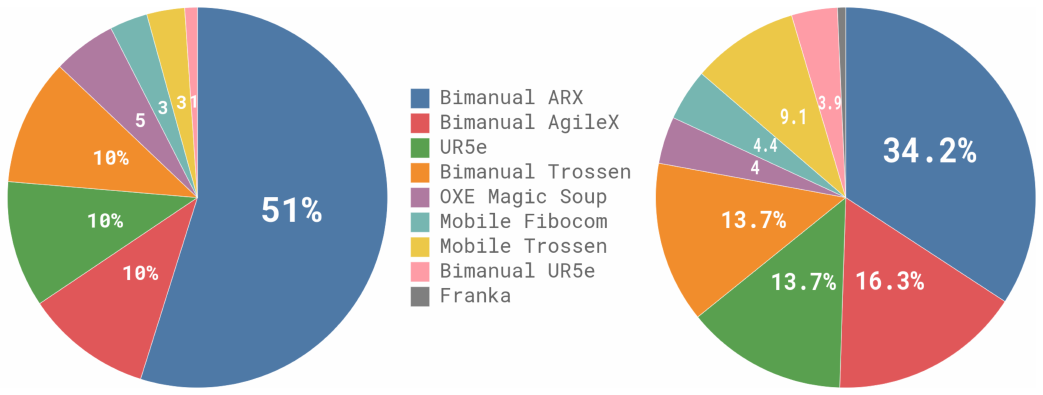

>左图 = 各数据集**相对规模**（时间步）；右图 = 各数据集在混合中的**权重**。两个口径不同，别混。

#### 语言标注与后训练数据

- 预训练同时使用**任务名**与**片段标注（segment annotations，约 2 秒粒度的子轨迹标签）**；
- 后训练数据量跨度很大：**最简单 5 小时，最复杂 100+ 小时**；

#### 训练配方：为什么"预训练 + 后训练"

- **预训练**：目标是广度——覆盖尽可能多的任务、任务内覆盖多样行为，让模型获得通用物理能力与**纠错能力**（低质量、多样的数据里才有失误与恢复行为）；
- **后训练**：目标是熟练——用高质量、行为一致流畅的数据，让模型把特定下游任务做好；
- 论文把它类比 LLM 的"预训练 + 对齐"，并指出机器人场景的差异：预训练模型有零样本能力，但叠衣服这类任务仍需后训练；只用高质量数据训出的模型**脆弱、不会纠错**，只零样本运行则**不够流畅**；
- 语言侧：π0 用**高层 VLM 策略**（SayCan 类）把"收拾餐桌"分解成"拿起餐巾""丢进垃圾桶"等中间指令，从而支持长程任务。

## Related Work

| 相关工作               | 它做了什么                                                   | π0 的差异                                                    |
| ---------------------- | ------------------------------------------------------------ | ------------------------------------------------------------ |
| RT-2 / RT-1            | 把动作离散成 256 桶当文本 token，自回归输出；RT-2 用 55B 级 VLM + 网络数据 co-fine-tuning | π0 走连续动作 + 流匹配 + 动作块，参数小得多，面向高频灵巧操作|
| OpenVLA                | 7B 开源 VLA，动作离散化 + Llama 特殊 token，强调开放权重与 LoRA/量化微调 | π0 不支持"逐 token 动作"路线；论文把 OpenVLA 的失败归因于不支持动作分块与高频控制 |
| Octo                   | 93M、用扩散生成动作，支持动作分块                            | π0 指出其表示能力有限         |
| ACT / Diffusion Policy | 专为小数据灵巧模仿设计，只在小数据集上训练                   | π0 用它们作为"无预训练"侧的强基线                  |
| Transfusion            | 单 Transformer 多目标（连续 token 用扩散损失、离散 token 用交叉熵） | π0 借用该思路，并额外使用**独立的 action expert 权重** |
| PaliGemma / Gemma 2B   | 开源 3B VLM（Gemma 2B + SigLIP 视觉塔）                      | π0 的底座；作者强调框架对任意 VLM 通用             |

## 优点与局限

**亮点**

- 动作表示层面给出了明确的替代路线：连续流匹配 + 动作块，使得"高频 + 灵巧 + 多本体"三者可以同时成立；
- 用受控消融支撑"预训练有用"这一结论（π0-small、from-scratch、out-of-box 三档对照）；
- 工程完备：缓存 KV 的 10 步推理、开环动作块执行、离板推理延迟都被量化；
- 任务难度显著上探：随机揉皱衣物、多件衣物连续折叠、组装纸箱等 5–20 分钟任务。

**局限与开放问题**

- 数据配方未解：作者自认不清楚"该加什么数据、怎么加权"最优；
- 基线公平性：OpenVLA 只训练 160k 步且架构不支持动作分块，π0-small 的比较又存在"参数更少"的混淆，作者明确承认难以消除；
- 统计强度有限：多数结论基于每任务 10 次试验，部分基线只在一个数据规模上评测；
- 任务与数据都来自自家体系，没有公共 benchmark 上的第三方复现；论文也未将"开源权重/代码"作为卖点（"open-source"在文中指数据集与 PaliGemma 底座）；
- 通用性边界未知：是否能扩展到自动驾驶、导航、足式运动等差异更大的领域仍待研究。

# π0.5

π0.5 不是彻底更换架构，而是在 π0 的视觉-语言-动作基础上，通过<mark>**异构数据协同训练**</mark>和<mark>**层级推理**</mark>，让机器人把网页知识、固定式机械臂经验、跨本体数据与移动机器人家庭数据结合起来，从而提升未见环境、未见指令和长时任务中的开放世界泛化能力。

## 相对 π0 的主要改进

| 维度     | π0.5 的做法                                                  | 作用/证据                                                    |
| -------- | ------------------------------------------------------------ | ------------------------------------------------------------ |
| 数据     | 引入 MM、ME、CE、HL、WD 等异构数据源                         | ME/CE 对通用操作能力关键；WD 对 OOD 指令理解和高层推理重要（见[消融实验](./paper.md#S031)–[数据结论](./paper.md#S037)） |
| 推理形式 | 先预测高层语义子任务，再条件生成低层动作                     | 将“要做什么”和“如何执行”分开，支持更长时程任务（见[层级推理](./paper.md#S024)） |
| 训练目标 | 预训练阶段使用 FAST 离散动作 token；后训练阶段加入 flow-matching action expert | 兼顾 VLM 的语义建模与连续动作生成|
| 泛化目标 | 训练地点与测试地点分离，并评估更多家庭规模                   | 在未见真实家庭和不同地点规模上测试开放世界泛化|

## 方法与训练流程

### 数据

| 数据源 | 主要信息                                 | 可能弥补的缺口                       |
| ------ | ---------------------------------------- | ------------------------------------ |
| MM     | 移动机器人在家庭中的视觉、语言、动作轨迹 | 真实家庭分布与移动操作经验           |
| ME     | 多环境固定式机械臂操作                   | 更丰富、更稳定的通用操作模式         |
| CE     | 不同机器人本体上的实验室任务             | 降低对单一本体和单一动作分布的依赖   |
| HL     | 高层子任务、框/语义标注                  | 学习任务分解与可解释的中间目标       |
| WD     | 网页图像描述、VQA、定位                  | 开放世界视觉知识、指令理解与语义推理 |

### 两阶段训练

1. **预训练（280k steps）**
   - 从网页预训练 VLM 初始化。
   - 使用 <mark>FAST 离散 token</mark> 做 next-token prediction。
   - 数据包括：
     - **MM**：约 400 小时、约 100 个家庭的移动机器人数据；
     - **ME**：多环境固定式机械臂数据；
     - **CE**：跨本体实验室任务；
     - **HL**：高层子任务/边界框标注；
     - **WD**：网页图像描述、VQA、定位等数据。
   - 关键观察：第一阶段约 97.6% 的样本并非移动家庭机器人数据，因此模型能力主要来自跨域组合，而非单纯扩大 MM 数据。

2. **后训练（80k steps，α=10）**
   - 使用 MM+ME 的成功短片段、WD、HL 子集和 VI 语言示范。
   - 增加随机初始化的 action expert，以 <mark>流匹配(flow matching)</mark> 生成连续动作。
   - 目标是把预训练得到的开放世界语义能力对齐到机器人控制。

### 推理时的层级结构

- 同一个模型先生成高层语义子任务。
- 再把该输出作为条件，生成低层连续动作。
- 控制频率：50 Hz。
- action horizon：50（文中记作 H=49）。
- 直观理解：高层输出提供可解释的“当前应完成什么”，低层策略负责“此刻如何移动执行”。

## 结果要点

- 完整 π0.5 优于 π0 和 π0-FAST+Flow。
- ME/CE 的移除会显著削弱通用操作能力。
- WD 的移除会削弱 OOD 指令理解和高层推理。
- 在高层推理实验中，完整模型超过 human-HL oracle，说明高层模块并非只是复制人工标注的子任务序列。
- 泛化收益随训练环境/地点规模增加而变化，但不能简单归因于环境数量；数据类型和任务覆盖同样重要。

## 失败模式与局限

- 新型把手或难以打开的柜门仍然容易失败。
- 部分可观测场景中，机械臂本身可能遮挡关键视觉信息。
- 高层预测可能被场景中的无关目标“分心”。
- 提示词、上下文长度和记忆能力仍有限，长任务中的历史信息利用不足。
- 许多定量多阶段消融主要在 mock homes 中完成，真实家庭中的结论仍需要更广泛验证。

## Q&A

### Q1：π0.5 相对 π0 的核心改进是什么？

**答题要点：** π0.5 延续 VLA 主体架构，重点改进在训练数据组合、层级推理和连续动作后训练。它把移动机器人、固定式机械臂、跨本体、网页视觉语言和高层标注数据结合起来，并先预测高层子任务，再生成低层动作，以提升开放世界泛化，而不是单纯增加模型规模。

### Q2：为什么预训练使用离散 action token，后训练改用 flow matching？

**答题要点：** 预训练需要统一处理文本、图像、标注和动作序列，离散 token 可以复用 VLM 的 next-token prediction 框架；后训练面向真实控制，连续动作更适合表达平滑、精确的机器人轨迹，flow matching 能减少离散化误差。简言之：预训练学习通用语义与行为先验，后训练把先验对齐到连续控制。    

**为什么 VLM 偏向离散 token：**

因为 VLM 已经擅长这样的任务：给定图片和前面的文字，预测接下来应该输出哪个 token。<br>
把动作也编码成 token 后，就可以沿用这种训练方式。

**flow matching 使用 VLM 的方式**
```text
图像 + 语言指令
        ↓
VLM 编码视觉、语言和任务信息
        ↓
得到连续的条件表示(Transformer 隐藏状态)
        ↓
action expert + flow matching
        ↓
连续动作序列
```

### Q3：为什么要混合异构数据，而不是只增加家庭机器人数据？

**答题要点：** 家庭机器人数据覆盖真实场景，但规模和任务多样性有限；固定式机械臂和跨本体数据提供更丰富的操作经验，网页数据提供开放世界语义知识，高层标注提供任务分解信号。消融表明 ME/CE 对通用操作重要，WD 对 OOD 指令理解和高层推理重要。

### Q4：π0.5 的层级推理具体是怎样的？

**答题要点：** 同一模型先生成高层语义子任务，例如当前应寻找、拿取或放置什么；随后将高层输出作为条件，生成低层连续动作。这样把长时程任务拆成语义决策和运动执行两个层次，控制器仍以 50 Hz 运行。

### Q5：层级推理为什么可能提升泛化？

**答题要点：** 高层子任务使用相对抽象、与具体机器人本体无关的语义表示，因此可以复用网页知识、跨本体数据和高层标注；低层动作则根据当前视觉状态和本体执行。抽象层减少了从单一动作分布直接外推到新环境的压力。但它也引入高层预测错误传播风险。

### Q6：π0.5 如何证明自己具有开放世界泛化能力？

**答题要点：** 测试家庭/地点不出现在训练中，并覆盖不同环境规模、任务和指令组合；实验持续 2–5 分钟，关注未见环境、物体、把手和长时任务。完整 π0.5 优于 π0 和 π0-FAST+Flow，说明收益不仅来自已有场景内的拟合。

### Q7：如何区分“数据规模收益”和“数据异质性收益”？

**答题要点：** 需要比较等规模但不同来源的数据，以及固定总训练步数下逐项移除 MM、ME、CE、HL、WD 的消融。论文的消融支持不同数据源承担不同能力，但严格因果拆分仍不充分，这是面试中可以主动指出的实验设计问题。

### Q8：为什么 ME 和 CE 对通用操作有帮助？

**答题要点：** ME 提供跨环境、较高密度的操作轨迹；CE 提供跨机器人本体的任务变化。二者共同扩大了可学习的物体交互和动作先验，减少策略把视觉模式错误绑定到某个家庭或机器人本体上。

### Q9：网页数据 WD 为什么能帮助机器人控制？

**答题要点：** WD 不直接提供完整机器人动作，而是增强物体识别、空间定位、语言理解和世界知识。通过高层推理，它可以把这些语义能力转化为更合理的子任务目标；但网页知识不能替代真实控制数据，最终仍需机器人轨迹后训练完成动作对齐。

### Q10：π0.5 为什么能超过 human-HL oracle？

**答题要点：** 论文报告完整模型在高层推理实验中超过 human-HL oracle。合理解释是模型不只复制人工高层标签，还能结合视觉状态、语言目标和自身策略产生更适合当前低层控制的子任务。面试时应补充：需要核对 oracle 的输入信息和评测协议，不能仅凭这个结果断言模型全面超过人类规划能力。

### Q11：π0.5 的主要失败模式是什么？

**答题要点：** 对新型把手和难开柜门仍不稳；机械臂遮挡会造成部分可观测；高层模块可能被无关目标分心；提示、上下文和记忆能力限制长任务表现；部分消融主要在 mock homes 中完成，真实家庭结论仍有外推风险。

### Q12：层级结构的主要风险是什么？

**答题要点：** 高层错误会向低层传播；高层更新频率过低可能无法响应快速变化；高层目标过于抽象会丢失控制所需细节；如果模型被场景中显著但无关的物体吸引，可能产生错误子任务。因此应研究高层置信度、重规划、低层拒绝执行和恢复策略。

### Q13：π0.5 的训练流程如何概括？

**答题要点：** 第一阶段预训练 280k steps，从网页预训练 VLM 初始化，以 FAST 离散 token 进行 next-token prediction；第二阶段后训练 80k steps、α=10，使用成功机器人片段、WD、HL 子集和 VI 语言示范，并加入随机初始化的连续 action expert，用 flow matching 对齐控制。

### Q14：为什么不能只用 flow matching 从头训练整个模型？

**答题要点：** 从头训练连续动作策略会失去成熟 VLM 的语言和视觉先验，并且难以高效吸收网页、多模态标注等非动作数据。π0.5 先用统一 token 目标学习广泛知识，再只在控制对齐阶段强化连续动作生成，训练效率和数据利用更合理。

### Q15：π0.5 的实验还有哪些不足？

**答题要点：** 多阶段消融未完全覆盖真实家庭；不同数据源的规模、质量和采样比例可能混杂；真实部署中的安全、碰撞率、人工接管成本和恢复策略报告不足；对长期记忆、异常状态和新本体迁移的评估仍有限。

### Q16：如果继续改进 π0.5，你会怎么做？

**答题要点：** 可考虑高层不确定性估计与动态重规划、动作安全过滤器、显式记忆/检索、失败轨迹和恢复数据训练、面向新本体的动作适配器，以及在真实家庭中进行等规模数据和严格因果消融。回答时要说明每项改进针对的具体失败模式，而不是只罗列技术名词。

### Q17：如何设计一个验证“层级推理确实有效”的实验？

**答题要点：** 保持模型、数据和训练预算一致，比较端到端动作生成、人工高层标签、模型高层预测和随机/扰动高层目标；在短任务、长任务、OOD 指令和部分可观测场景分别报告成功率、恢复次数、任务时长和高层错误率。这样可以区分层级结构本身、标签质量和额外监督的作用。

### Q18：如何用一句话评价 π0.5？

**参考回答：** π0.5 的贡献是把 VLA 的泛化问题从“只收集更多同分布机器人轨迹”转化为“用异构数据学习语义与操作先验，再通过层级推理和连续动作专家落地控制”；它展示了有效方向，但高层错误传播、真实家庭验证和安全部署仍是主要开放问题。